# Phân Tích Thời Gian Chờ (Bank Wait Time vs Customer Wait Time)

Trong file này, chúng ta sẽ bóc tách:
- **Customer Wait Time (Khách hàng ngâm):** Thời gian từ lúc ngân hàng gửi Offer (`O_Sent (mail and online)`) đầu tiên đến lúc nhận được phản hồi từ khách (`O_Returned`) đầu tiên.
- **Bank Wait Time (Ngân hàng duyệt):** Thời gian từ lúc nhận phản hồi (`O_Returned`) đến lúc ngân hàng đưa ra phán quyết sau khi thẩm định (Có thể là `A_Incomplete` - thiếu hồ sơ, `A_Pending` - chờ giải ngân, `A_Accepted`, hoặc `A_Denied`).

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [19]:
# 1. Đọc dữ liệu
data_path = 'data/bpi-challenge-2017/bpi_2017_cleaned.csv'
df = pd.read_csv(data_path)

# Chuyển đổi timestamp sang dạng datetime (UTC), xử lý format mixed
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], utc=True, format='mixed')

# Sắp xếp dữ liệu theo thứ tự thời gian của từng case
df = df.sort_values(by=['case:concept:name', 'time:timestamp'])

print(f"Tổng số events: {len(df)}")
print(f"Tổng số cases: {df['case:concept:name'].nunique()}")

Tổng số events: 1202267
Tổng số cases: 31509


In [ ]:
# 2. Trích xuất thời điểm quan trọng cho từng Case

# 2.1 Customer Wait: Lấy O_Sent và O_Returned đầu tiên
o_sent = df[df['concept:name'] == 'O_Sent (mail and online)'].groupby('case:concept:name')['time:timestamp'].min().reset_index(name='time_sent')
o_returned = df[df['concept:name'] == 'O_Returned'].groupby('case:concept:name')['time:timestamp'].min().reset_index(name='time_returned')

# 2.2 Bank Wait: Lấy hành động thẩm định xong của ngân hàng SAU KHI nhận O_Returned
bank_decisions = df[df['concept:name'].isin(['A_Pending', 'A_Incomplete', 'A_Accepted', 'A_Denied', 'A_Cancelled'])]

# Nối với o_returned để đảm bảo hành động này xảy ra sau O_Returned
bank_decisions = bank_decisions.merge(o_returned, on='case:concept:name')
bank_decisions = bank_decisions[bank_decisions['time:timestamp'] >= bank_decisions['time_returned']]

# Lấy hành động đầu tiên sau O_Returned
time_bank_decision = bank_decisions.groupby('case:concept:name')['time:timestamp'].min().reset_index(name='time_bank_decision')

# Merge tất cả lại
wait_df = o_sent.merge(o_returned, on='case:concept:name', how='inner')
wait_df = wait_df.merge(time_bank_decision, on='case:concept:name', how='inner')

# Lọc bỏ những dữ liệu lỗi (âm thời gian)
wait_df = wait_df[(wait_df['time_sent'] <= wait_df['time_returned']) & (wait_df['time_returned'] <= wait_df['time_bank_decision'])]

print(f"Số lượng case hợp lệ tính toán: {len(wait_df)}")

Số lượng case hợp lệ tính toán: 21538


In [21]:
# 3. Tính toán Customer Wait Time và Bank Wait Time (đơn vị: Ngày)
wait_df['customer_wait_days'] = (wait_df['time_returned'] - wait_df['time_sent']).dt.total_seconds() / (24 * 3600)
wait_df['bank_wait_days'] = (wait_df['time_bank_decision'] - wait_df['time_returned']).dt.total_seconds() / (24 * 3600)

print("=== Thống kê Customer Wait Time (Ngày) ===")
print(wait_df['customer_wait_days'].describe())

print("\n=== Thống kê Bank Wait Time (Ngày) ===")
print(wait_df['bank_wait_days'].describe())

=== Thống kê Customer Wait Time (Ngày) ===
count    21538.000000
mean        10.057199
std          6.806166
min          0.000061
25%          5.949543
50%          7.847946
75%         12.179354
max         80.015503
Name: customer_wait_days, dtype: float64

=== Thống kê Bank Wait Time (Ngày) ===
count    21538.000000
mean         2.350607
std          2.739631
min          0.000018
25%          0.177467
50%          1.294059
75%          3.994829
max         92.051619
Name: bank_wait_days, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_3324\1516636702.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Khách hàng giữ Offer', 'Ngân hàng chờ thẩm định'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_3324\1516636702.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Khách hàng giữ', 'Ngân hàng thẩm định'], y=mean_waits, ax=axes[1], palette='Set2')


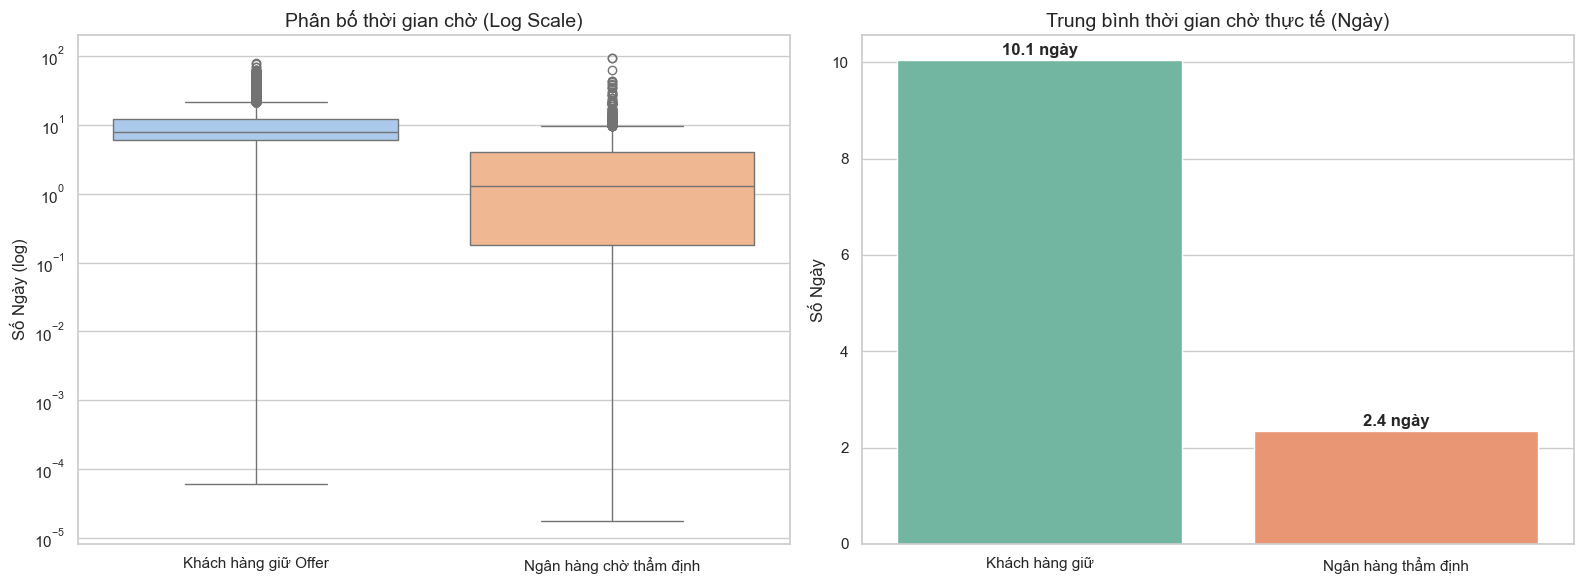

In [22]:
# 4. Trực quan hóa so sánh trực quan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Boxplot so sánh độ phân tán
sns.boxplot(data=wait_df[['customer_wait_days', 'bank_wait_days']], ax=axes[0], palette='pastel')
axes[0].set_yscale('log') # Dùng log scale vì có các hồ sơ bị ngâm cả tháng (outliers)
axes[0].set_title('Phân bố thời gian chờ (Log Scale)', fontsize=14)
axes[0].set_ylabel('Số Ngày (log)')
axes[0].set_xticklabels(['Khách hàng giữ Offer', 'Ngân hàng chờ thẩm định'])

# Biểu đồ Barplot so sánh giá trị trung bình
mean_waits = [wait_df['customer_wait_days'].mean(), wait_df['bank_wait_days'].mean()]
sns.barplot(x=['Khách hàng giữ', 'Ngân hàng thẩm định'], y=mean_waits, ax=axes[1], palette='Set2')
axes[1].set_title('Trung bình thời gian chờ thực tế (Ngày)', fontsize=14)
axes[1].set_ylabel('Số Ngày')

# Hiển thị con số cụ thể trên cột
for i, v in enumerate(mean_waits):
    axes[1].text(i, v + 0.1, f"{v:.1f} ngày", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

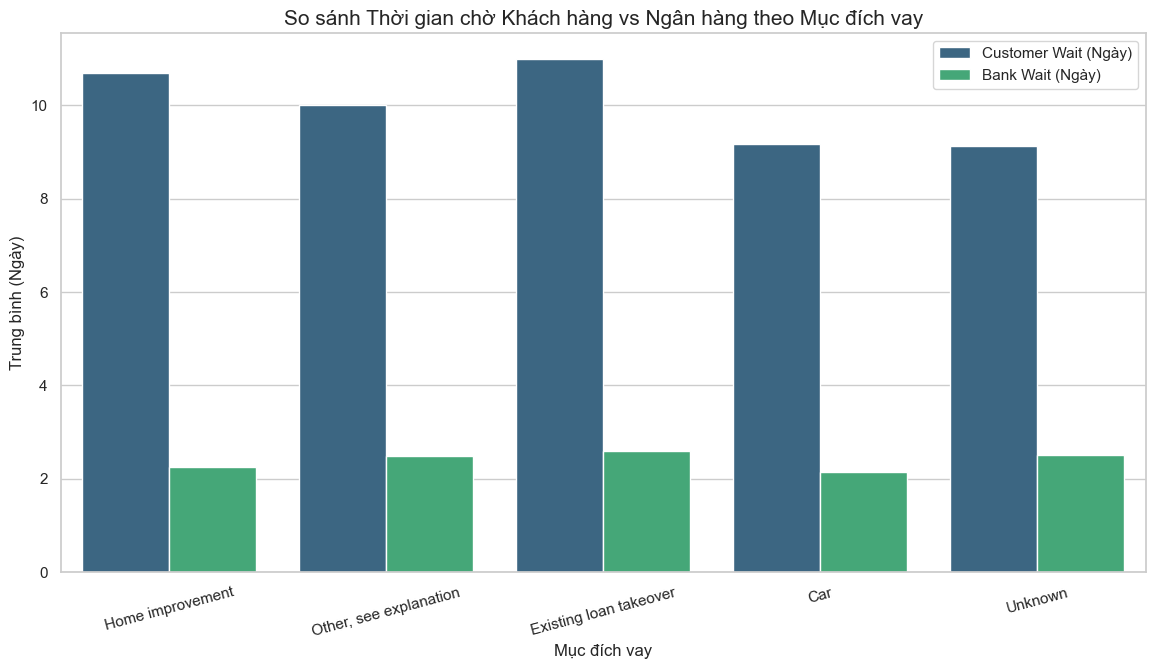

In [23]:
# 5. Lấy LoanGoal từ dữ liệu gốc nối vào bảng Wait Time
app_info = df[df['concept:name'] == 'A_Create Application'][['case:concept:name', 'case:ApplicationType', 'case:LoanGoal']].drop_duplicates()

wait_df = wait_df.merge(app_info, on='case:concept:name', how='left')

# Trực quan hóa theo LoanGoal
top_goals = wait_df['case:LoanGoal'].value_counts().head(5).index # Chỉ lấy 5 mục đích vay phổ biến nhất
plot_df = wait_df[wait_df['case:LoanGoal'].isin(top_goals)].copy()

# Melting dataframe để vẽ barplot grouped dễ dàng hơn
melted_df = plot_df.melt(id_vars=['case:concept:name', 'case:LoanGoal'], 
                         value_vars=['customer_wait_days', 'bank_wait_days'],
                         var_name='Wait_Type', value_name='Days')

plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x='case:LoanGoal', y='Days', hue='Wait_Type', palette='viridis', errorbar=None)
plt.title('So sánh Thời gian chờ Khách hàng vs Ngân hàng theo Mục đích vay', fontsize=15)
plt.ylabel('Trung bình (Ngày)')
plt.xlabel('Mục đích vay')
plt.xticks(rotation=15)
plt.legend(['Customer Wait (Ngày)', 'Bank Wait (Ngày)'])
plt.show()

1. 
- Nhìn vào biểu đồ cột (Barplot), thời gian Khách hàng ngâm hồ sơ trung bình lên tới 10.1 ngày, cao gấp 4 lần so với thời gian Ngân hàng xử lý/thẩm định (2.4 ngày).
Insight: Ngân hàng đang làm việc với hiệu suất rất tốt (chỉ mất hơn 2 ngày để xử lý xong một đống giấy tờ trả về). Nguyên nhân khiến toàn bộ quy trình vay bị kéo dài lê thê không nằm ở nội bộ ngân hàng, mà là do khách hàng thiếu chủ động trong việc bổ sung giấy tờ và ký gửi lại Offer.
2.
-  Sự đồng nhất đáng kinh ngạc trong khâu xử lý của Ngân Hàng (Standardized Process)
Nhìn vào biểu đồ Barplot thứ hai (phân nhóm theo Mục đích vay - Loan Goal), bạn sẽ thấy các cột màu xanh lá (Bank Wait) gần như bằng phẳng y hệt nhau ở mức ~2.4 ngày cho mọi loại hồ sơ (từ Mua xe, Sửa nhà cho đến Đảo nợ).
Insight: Hệ thống vận hành (Back-office) của ngân hàng được chuẩn hóa cực kỳ tốt. Nhân viên không hề có sự phân biệt đối xử hay ưu tiên xử lý nhanh/chậm cho bất kỳ loại khoản vay nào. Cứ nhận được hồ sơ là họ xử lý xong trong khung thời gian chuẩn.
3.
-  Giải thích hành vi Khách hàng theo Mục đích vay (Behavioral Insight)
Tuy ngân hàng xử lý đồng đều, nhưng hành vi ngâm hồ sơ của khách hàng (cột màu xanh dương) lại có sự khác biệt thú vị:

Vay đảo nợ (Existing loan takeover) bị ngâm lâu nhất (hơn 11 ngày): Điều này cực kỳ hợp lý về mặt logic nghiệp vụ (Business Logic). Khách hàng vay đảo nợ thường phải chạy qua chạy lại giữa 2 ngân hàng (ngân hàng cũ để xin giấy phép tất toán, và ngân hàng mới để nộp hồ sơ). Thủ tục rườm rà khiến họ mất nhiều thời gian để gửi lại Offer.
Vay mua xe (Car) nhanh hơn (khoảng 9 ngày): Tâm lý người đi mua xe thường háo hức và muốn chốt deal nhanh với showroom, nên họ có xu hướng hoàn thiện và gửi lại hồ sơ cho ngân hàng nhanh hơn.